In [13]:
import pandas as pd
# Load the dataset
df = pd.read_csv("../data/processed/economic_health_scores.csv")
print(df.head())

                  Country Name Country Code  Year           GDP  GDP_Growth  \
0  Africa Eastern and Southern          AFE  1991  2.769185e+11    0.423805   
1                    Australia          AUS  1991  3.264164e+11    0.421958   
2                      Austria          AUT  1991  1.731134e+11    0.447319   
3                      Belgium          BEL  1991  2.105110e+11    0.436657   
4                 Burkina Faso          BFA  1991  3.135046e+09    0.484624   

   Inflation  Unemployment   Population   Exports  Economic_Health_Score  
0   0.001452      0.205447  320442961.0  0.080508               0.544244  
1   0.000842      0.245116   17284036.0  0.069878               0.533567  
2   0.000849      0.085788    7754891.0  0.151628               0.591926  
3   0.000844      0.177881   10004486.0  0.263001               0.591518  
4   0.000800      0.061163    9394632.0  0.045601               0.590577  


In [14]:
featuers = ["GDP_Growth", "Unemployment", "Inflation", "Exports"]
x = df[featuers]
print(x.head())

   GDP_Growth  Unemployment  Inflation   Exports
0    0.423805      0.205447   0.001452  0.080508
1    0.421958      0.245116   0.000842  0.069878
2    0.447319      0.085788   0.000849  0.151628
3    0.436657      0.177881   0.000844  0.263001
4    0.484624      0.061163   0.000800  0.045601


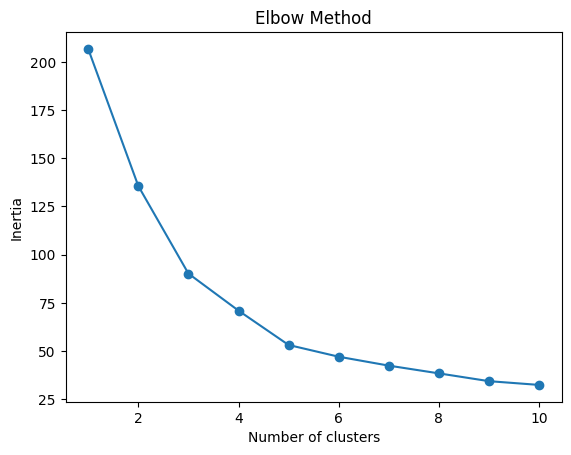

In [15]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(x)
    inertia.append(kmeans.inertia_)
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()


In [16]:
Kmeans = KMeans(n_clusters=3, random_state=42)
df["Cluster"] = Kmeans.fit_predict(x)

In [17]:
clusters = df.groupby("Cluster")["Country Name"].apply(list)
print(clusters)

Cluster
0    [Africa Eastern and Southern, Australia, Austr...
1    [Belgium, Bahrain, Hong Kong SAR, China, Luxem...
2    [Bahamas, The, Botswana, Congo, Rep., Cabo Ver...
Name: Country Name, dtype: object


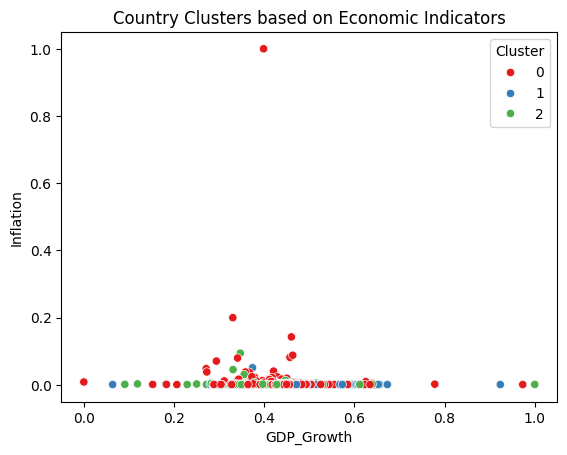

In [18]:
import seaborn as sns
sns.scatterplot(data=df, x="GDP_Growth", y="Inflation", hue="Cluster", palette="Set1")
plt.title("Country Clusters based on Economic Indicators")
plt.show()


In [19]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(x)

df["PCA1"] = X_pca[:,0]
df["PCA2"] = X_pca[:,1]

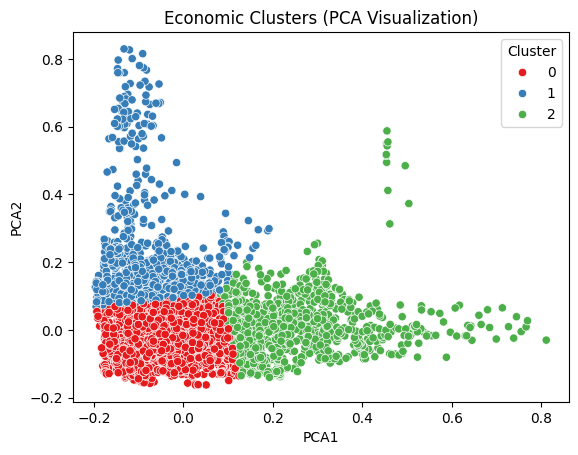

In [20]:
sns.scatterplot(
    data=df,
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    palette="Set1"
)

plt.title("Economic Clusters (PCA Visualization)")
plt.show()

In [21]:
df.groupby("Cluster")[["GDP_Growth","Inflation","Unemployment","Exports"]].mean()

,GDP_Growth,Inflation,Unemployment,Exports
Cluster,,,,
0,0.448800,0.001494,0.150265,0.124298
1,0.452810,0.000965,0.127894,0.379152
2,0.442386,0.001286,0.440137,0.165032


In [23]:
print(df.head())

                  Country Name Country Code  Year           GDP  GDP_Growth  \
0  Africa Eastern and Southern          AFE  1991  2.769185e+11    0.423805   
1                    Australia          AUS  1991  3.264164e+11    0.421958   
2                      Austria          AUT  1991  1.731134e+11    0.447319   
3                      Belgium          BEL  1991  2.105110e+11    0.436657   
4                 Burkina Faso          BFA  1991  3.135046e+09    0.484624   

   Inflation  Unemployment   Population   Exports  Economic_Health_Score  \
0   0.001452      0.205447  320442961.0  0.080508               0.544244   
1   0.000842      0.245116   17284036.0  0.069878               0.533567   
2   0.000849      0.085788    7754891.0  0.151628               0.591926   
3   0.000844      0.177881   10004486.0  0.263001               0.591518   
4   0.000800      0.061163    9394632.0  0.045601               0.590577   

   Cluster      PCA1      PCA2  
0        0  0.019008 -0.082992  
1 

In [24]:
df.to_csv("../data/processed/Economic_clusters.csv", index=False)